#Variational PINNs
we will implement variational PINNs to solve the steady-state Burger's equation in 1D:
\begin{align}
&u\frac{{\rm d}u}{{\rm d}x} - \frac{{\rm d}^2u}{{\rm d}x^2} = f(x), x\in (-1,1),\\
&u(-1)=g,\ u(1)=h.
\end{align}

As a comparison reference, we consider the manufactured solution
$$u_{\rm exact}(x) = (1-x^2)\sin(2x),$$
which implies the boundary conditions $h=g=0$ and the forcing term $$f(x) = x(x^2-1) + (6-4x^2)\sin(2x) + 8x\cos(2x) + (x^2-1)^2\sin(4x) - x(x^2-1)\cos(4x).$$

##Weak Form
Let $$\mathcal{U} = \left\{ u\in H^1(\Omega)\mid u(-1)=g,\ u(1)=h\right\}$$ and $$\mathcal{V} = \left\{ v\in H^1(\Omega)\mid v(-1)=0,\ v(1)=0\right\}$$ be the *trial* and *test* spaces, respectively, over the domain $\Omega = [-1,1]$.
By multiplying both sides of the differential equation by a test function $v\in \mathcal{V}$ and integrating over the domain $\Omega$, we have
\begin{align}
\int_{\Omega} \left\{ u\frac{{\rm d}u}{{\rm d}x} - \frac{{\rm d}^2u}{{\rm d}x^2} \right\}v(x)\ {\rm d}x = \int_{\Omega} f(x)v(x)\ {\rm d}x
\end{align}
By integrating by parts and using the fact that $v$ vanishes at the boundary, we obtain the weak form
\begin{align}
\int_{\Omega} \left\{ -\frac{u^2}{2} + \frac{{\rm d}u(x)}{{\rm d}x} \right\} \frac{{\rm d}v(x)}{{\rm d}x}\ {\rm d}x = \int_{\Omega} f(x)v(x)\ {\rm d}x.
\end{align}
Now, solution of the original differential equation amounts to solving the following problem: find $u\in \mathcal{U}$ such that
\begin{align}
\mathcal{R}(u,v)={\mathbf a}(u,v)-{\mathbf b}(v)=0,\ \forall v \in \mathcal{V},
\end{align}
where the residual $\mathcal{R}(u,v)$ is defined by the *bilinear form* ${\mathbf a}(u,v)$ and the *linear functional* ${\mathbf b}(v)$:
\begin{align}
&{\mathbf a}(u,v) := \int_{\Omega} \left\{ -\frac{u^2}{2} + \frac{{\rm d}u(x)}{{\rm d}x} \right\} \frac{{\rm d}v(x)}{{\rm d}x}\ {\rm d}x \\
&{\mathbf b}(v):=\int_{\Omega} f(x)v(x)\ {\rm d}x.
\end{align}

###Variational PINN
We approximate the trial function using NNs:
\begin{align}
u(x)\approx u_{\rm NN}(x; \theta),
\end{align}
where $\theta$ is the vector of network's parameters (weights and biases).
Let $\{v_k\}_{k=1}^{N_v}\subset \mathcal{V}$ be a set of independent test functions; we form the following comulative loss for the training:
\begin{align}
&\mathcal{L} = \frac{1}{2N_v}\sum_{k=1}^{N_v} \mathcal{R}^2[u_{\rm NN},v_k] + \lambda_{{\rm BC}} \mathcal{L}_{\rm BC},\\
&\mathcal{L}_{\rm BC} = \frac{1}{2} \left(  |u_{\rm NN}(-1)-g|^2 + |u_{\rm NN}(1)-h|^2 \right)
\end{align}
where $\mathcal{L}_{{\rm BC}}$ is a term to enforce the essential boundary conditions with the relative weight $\lambda_{\rm BC}>0$.

Installing `equinox` (required in Colab):

In [ ]:
!pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.8 MB/s eta 0:00:00


Required imports:

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import equinox as eqx
import optax
import matplotlib.pyplot as plt

Domain:

In [ ]:
x_min, x_max = -1.0, 1.0

Forcing term, $f(x)$:

In [ ]:
def forcing_term(x):
  f = x*(x**2 - 1) \
    + (6 - 4*x**2)*jnp.sin(2*x) \
    + 8*x*jnp.cos(2*x) \
    + (x**2 - 1)**2 * jnp.sin(4*x) \
    - x*(x**2 - 1)*jnp.cos(4*x)
  return f

##Gaussian Quadrature

In [ ]:
GQ_order = 6 # order
x_GQ, w_GQ = np.polynomial.legendre.leggauss(GQ_order) # nodes and weights
x_GQ = jnp.asarray(x_GQ)
w_GQ = jnp.asarray(w_GQ)

# Transformin the nodes
x_GQ = 0.5 * (x_max - x_min) * x_GQ + 0.5 * (x_max + x_min)
# Jacobian factor
jacob_factor = 0.5 * (x_max - x_min)

##Trial Function
We use an MLP to approximate the trial function, $u(x)\approx {\rm MLP}(x;\theta)$:

In [ ]:
key = jax.random.PRNGKey(0)
key, init_key = jax.random.split(key)

trial_NN = eqx.nn.MLP(
    in_size='scalar',
    out_size='scalar',
    width_size=3,
    depth=1,
    activation=jnp.sin,
    key=init_key
)

##Test Functions


In [ ]:
def test_func(n):
  n = int(n) # should be an integer>=1
  def v(x):
    return (1 - x**2) * jnp.sin(n*x)

  return v

plotting a few of test functions:

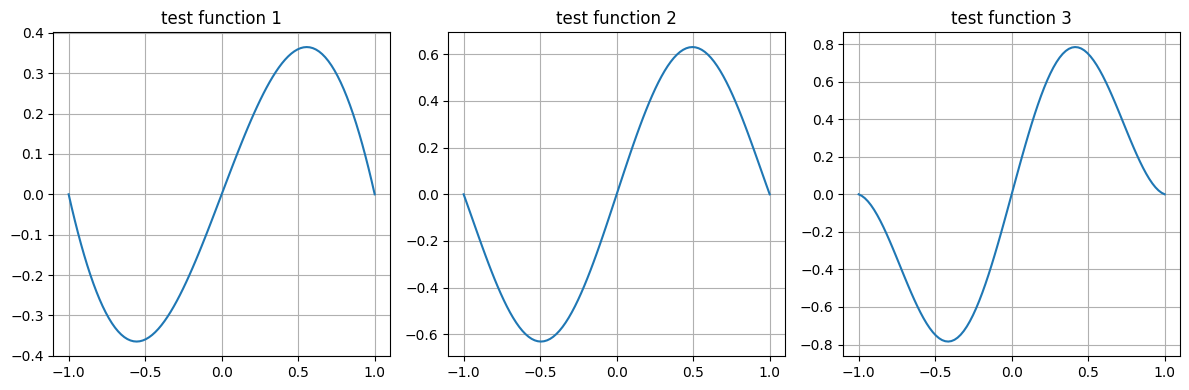

In [ ]:
x_plt = jnp.linspace(x_min, x_max, 100)
plt.figure(figsize=(12,4))
for i in range(3):
  plt.subplot(1,3,i+1)
  plt.plot(x_plt, jax.vmap(test_func(i+1))(x_plt))
  plt.grid()
  plt.title(f'test function {i+1}')
plt.tight_layout()
plt.show()

##Residual & Loss

In [ ]:
def bilinear_form_integrand(u_trial, v_test, x):
  a_uv = (-0.5*u_trial(x)**2 + jax.grad(u_trial)(x)) * jax.grad(v_test)(x)
  return a_uv

def linear_functional_integrand(v_test, x):
  b_v = forcing_term(x) * v_test(x)
  return b_v

def residual_density(u_trial, v_test, x):
  r = bilinear_form_integrand(u_trial, v_test, x) - linear_functional_integrand(v_test, x)
  return r

In [ ]:
def residual(u_trial, v_test):
  R = jax.vmap(residual_density, in_axes=(None, None, 0))(u_trial, v_test, x_GQ)
  return jacob_factor * jnp.sum(w_GQ * R)

In [ ]:
residual_density(trial_NN, test_func(1), 0.4)
print(residual(trial_NN, test_func(1)))

-2.2602005


###NN Loss Function:

In [ ]:
number_of_test_functions = 2

def loss_NN(network):
  L = 0.0
  for kk in range(number_of_test_functions):
    L += 0.5 * residual(network, test_func(kk))**2 / number_of_test_functions
  return L

In [ ]:
print(loss_NN(trial_NN))

1.2771266


###Boundary Loss

In [ ]:
def loss_BC(network):
  return 0.5 * network(x_min)**2 + 0.5 * network(x_max)**2

In [ ]:
print(loss_BC(trial_NN))

0.16091269


##Total Loss

In [ ]:
L0_NN = loss_NN(trial_NN)
L0_BC = loss_BC(trial_NN)
lambda_BC = (L0_BC + 1e-012) / (L0_NN + 1e-012)
print(lambda_BC)
def loss_total(network):
  return loss_NN(network) + lambda_BC * loss_BC(network)

0.12599589


In [ ]:
loss_total(trial_NN)

Array(1.2974008, dtype=float32)

##Training

In [ ]:
l_rate = 1e-02
optimizer = optax.sgd(learning_rate=l_rate)
opt_state = optimizer.init(eqx.filter(trial_NN, eqx.is_array))

In [ ]:
@eqx.filter_jit
def make_step(network, state):
  loss, grads = eqx.filter_value_and_grad(loss_total)(network)
  updates, new_state = optimizer.update(grads, state)
  new_network = eqx.apply_updates(network, updates)
  return loss, new_network, new_state

In [ ]:
num_epochs = 15_000
loss_history = []

for epoch in range(num_epochs):
  loss_value, trial_NN, opt_state = make_step(trial_NN, opt_state)
  loss_history.append(loss_value)

  if epoch % 1000 == 0:
    print(f"Epoch {epoch}, Loss: {loss_value}")

Epoch 0, Loss: 1.2974008321762085
Epoch 1000, Loss: 0.033170584589242935
Epoch 2000, Loss: 2.586830305517651e-05
Epoch 3000, Loss: 2.0220678464966113e-08
Epoch 4000, Loss: 7.017261771657957e-11
Epoch 5000, Loss: 4.734724765032006e-11
Epoch 6000, Loss: 3.3263551635354105e-11
Epoch 7000, Loss: 2.2114771819348178e-11
Epoch 8000, Loss: 1.582145872647267e-11
Epoch 9000, Loss: 1.2269872617931554e-11
Epoch 10000, Loss: 9.978917865638426e-12
Epoch 11000, Loss: 9.978917865638426e-12
Epoch 12000, Loss: 9.978917865638426e-12
Epoch 13000, Loss: 9.978917865638426e-12
Epoch 14000, Loss: 9.978917865638426e-12


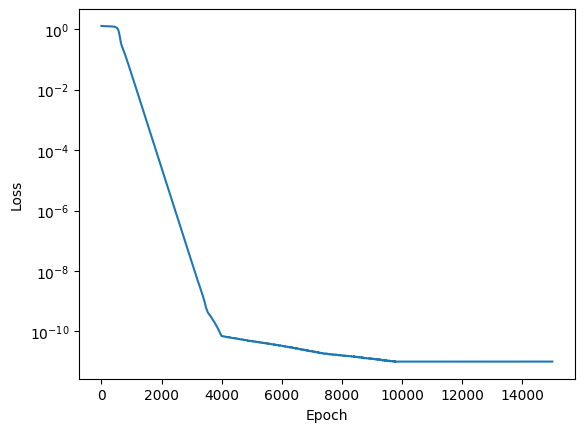

In [ ]:
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

##Projected (Bubnov–Galerkin) Solution
For comparison, we consider the case that the trial function lies in the subspace spanned by the test functions, $u\in {\rm span}\{v_k\}_{k=1}^{N_v}$. This amounts to a least-squares projection of $u$ onto this subspace $u_{\rm proj} = \underline{\alpha}^\top \underline{v}$, $\underline{v} = {\rm col}(v_k)_{k=1}^{N_v}$, which is obtained by solving the normal equation
\begin{align}
A\underline{\alpha} = \underline{b},
\end{align}
where
\begin{align}
&A_{ij} = {\mathbf a}(v_i, v_j),\\
&b_{i} = {\mathbf b}(v_i).
\end{align}

In [ ]:
A = jnp.zeros((number_of_test_functions, number_of_test_functions))
b = jnp.zeros((number_of_test_functions, ))

for i in range(number_of_test_functions):
  b = b.at[i].set( jacob_factor * jnp.sum(jax.vmap(linear_functional_integrand,
                              in_axes=(None,0))(test_func(i+1), x_GQ) * w_GQ ) )
  for j in range(i,number_of_test_functions):
    A = A.at[i,j].set( jacob_factor * jnp.sum(jax.vmap(bilinear_form_integrand,
          in_axes=(None,None,0))(test_func(i+1), test_func(j+1), x_GQ) * w_GQ) )

print(A)
print(b)
A = A + A.T - jnp.diag(jnp.diag(A))
coefs = jnp.linalg.solve(A, b)
def sol_proj(x):
  u = 0.0
  for i in range(number_of_test_functions):
    u += coefs[i] * test_func(i)(x)
  return u

print(A)
print(b)

[[1.3926047 2.2799757]
 [0.        3.8844178]]
[2.2541025 3.9366684]
[[1.3926047 2.2799757]
 [2.2799757 3.8844178]]
[2.2541025 3.9366684]


##Results

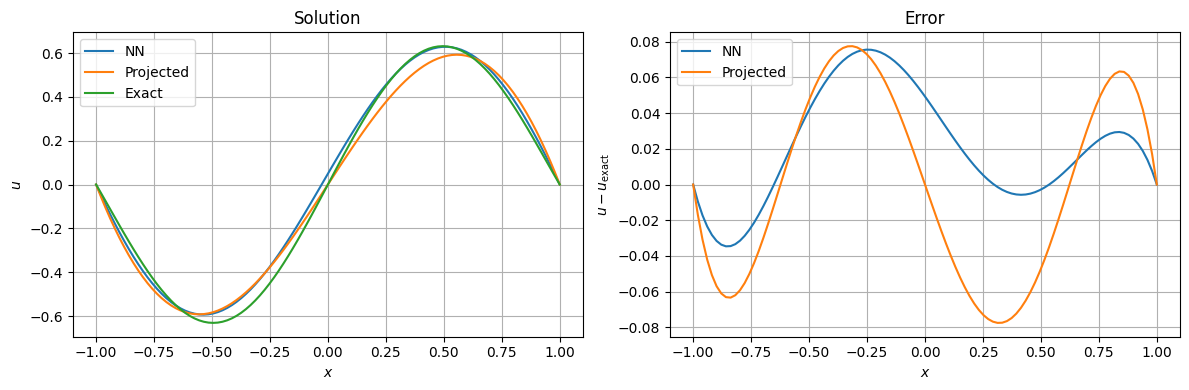

In [ ]:
x_grid = jnp.linspace(x_min, x_max, 100)
u_NN = jax.vmap(trial_NN)(x_grid)
u_proj = jax.vmap(sol_proj)(x_grid)
u_exact = (1 - x_grid**2) * jnp.sin(2 * x_grid)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_grid, u_NN, label='NN')
plt.plot(x_grid, u_proj, label='Projected')
plt.plot(x_grid, u_exact, label='Exact')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.grid()
plt.legend()
plt.title('Solution')

plt.subplot(1,2,2)
plt.plot(x_grid, u_NN - u_exact, label='NN')
plt.plot(x_grid, u_proj - u_exact, label='Projected')
plt.xlabel(r'$x$')
plt.ylabel(r'$u - u_{\rm exact}$')
plt.grid()
plt.legend()
plt.title('Error')
plt.tight_layout()
plt.show()